### First of all Load Data using Pandas

In [2]:
import pandas as pd
df = pd.read_csv('/kaggle/input/datasets/yasserh/walmart-dataset/Walmart.csv')
display(df)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667


### Do Some initial Analysis

In [3]:
df.columns

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [5]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [6]:
df['Fuel_Price'].duplicated().sum()

np.int64(5543)

## Temporal Feature Engineering

In [7]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

### Now Extract the Month, Week of Year and Quarter

In [8]:
df['Year'] = df['Date'].dt.year
df['Month_Name'] = df['Date'].dt.month_name()
df['Week_of_Year'] = df['Date'].dt.isocalendar().week.astype(int)
df['Quarter'] = df['Date'].dt.quarter

### Now we Place Flag on week before Christmas

In [9]:
df['christmas_week'] = pd.to_datetime(
    df['Year'].astype(str) + '-12-25').dt.isocalendar().week.astype(int)

In [10]:
df['is_christmas_week'] = (df['Week_of_Year'] == (df['christmas_week'] - 1)).astype(int)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Store              6435 non-null   int64         
 1   Date               6435 non-null   datetime64[ns]
 2   Weekly_Sales       6435 non-null   float64       
 3   Holiday_Flag       6435 non-null   int64         
 4   Temperature        6435 non-null   float64       
 5   Fuel_Price         6435 non-null   float64       
 6   CPI                6435 non-null   float64       
 7   Unemployment       6435 non-null   float64       
 8   Year               6435 non-null   int32         
 9   Month_Name         6435 non-null   object        
 10  Week_of_Year       6435 non-null   int64         
 11  Quarter            6435 non-null   int32         
 12  christmas_week     6435 non-null   int64         
 13  is_christmas_week  6435 non-null   int64         
dtypes: datet

In [12]:
df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month_Name,Week_of_Year,Quarter,christmas_week,is_christmas_week
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,February,5,1,51,0
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,February,6,1,51,0
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,February,7,1,51,0
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,February,8,1,51,0
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,March,9,1,51,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6430,45,2012-09-28,713173.95,0,64.88,3.997,192.013558,8.684,2012,September,39,3,52,0
6431,45,2012-10-05,733455.07,0,64.89,3.985,192.170412,8.667,2012,October,40,4,52,0
6432,45,2012-10-12,734464.36,0,54.47,4.000,192.327265,8.667,2012,October,41,4,52,0
6433,45,2012-10-19,718125.53,0,56.47,3.969,192.330854,8.667,2012,October,42,4,52,0


### Now we are going to Observe the Outliars

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='Weekly_Sales'>

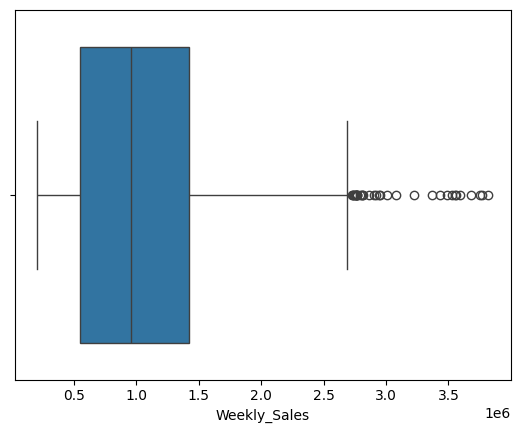

In [14]:
sns.boxplot(x=df['Weekly_Sales'])

In [15]:
df.describe()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Week_of_Year,Quarter,christmas_week,is_christmas_week
count,6435.000000,6435,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,2011-06-17 00:00:00,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151,2010.965035,25.818182,2.482517,51.300699,0.013986
min,1.000000,2010-02-05 00:00:00,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000,2010.000000,1.000000,1.000000,51.000000,0.000000
25%,12.000000,2010-10-08 00:00:00,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000,2010.000000,14.000000,2.000000,51.000000,0.000000
50%,23.000000,2011-06-17 00:00:00,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000,2011.000000,26.000000,2.000000,51.000000,0.000000
75%,34.000000,2012-02-24 00:00:00,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000,2012.000000,38.000000,3.000000,52.000000,0.000000
max,45.000000,2012-10-26 00:00:00,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000,2012.000000,52.000000,4.000000,52.000000,1.000000
std,12.988182,NaN,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885,0.797019,14.129201,1.070036,0.458598,0.117442


### Lets we Deal with Ouliars

In [16]:
Q1 = df['Weekly_Sales'].quantile(0.25)
Q3 = df['Weekly_Sales'].quantile(0.75)
IQR = Q3-Q1

In [17]:
Lower_bound = Q1 - (1.5 * IQR)
Upper_bound = Q3 + (1.5 * IQR)
display(Lower_bound)
display(Upper_bound)

    

np.float64(-746862.7275)

np.float64(2720371.4924999997)

### Now Replace all these Outliars with Median 

In [18]:
median_val = df['Weekly_Sales'].median()
df['Cleaned_Weekly_Sales'] = df['Weekly_Sales'].where(
    df['Weekly_Sales'].between(Lower_bound,Upper_bound), other = median_val
)

In [19]:
df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month_Name,Week_of_Year,Quarter,christmas_week,is_christmas_week,Cleaned_Weekly_Sales
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,February,5,1,51,0,1643690.90
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,February,6,1,51,0,1641957.44
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,February,7,1,51,0,1611968.17
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,February,8,1,51,0,1409727.59
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,March,9,1,51,0,1554806.68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6430,45,2012-09-28,713173.95,0,64.88,3.997,192.013558,8.684,2012,September,39,3,52,0,713173.95
6431,45,2012-10-05,733455.07,0,64.89,3.985,192.170412,8.667,2012,October,40,4,52,0,733455.07
6432,45,2012-10-12,734464.36,0,54.47,4.000,192.327265,8.667,2012,October,41,4,52,0,734464.36
6433,45,2012-10-19,718125.53,0,56.47,3.969,192.330854,8.667,2012,October,42,4,52,0,718125.53


<Axes: xlabel='Cleaned_Weekly_Sales'>

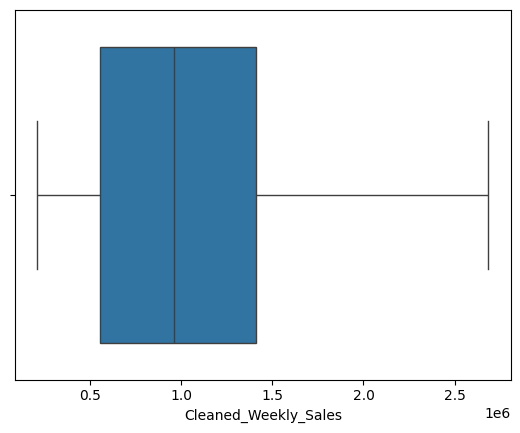

In [20]:
sns.boxplot(x=df['Cleaned_Weekly_Sales'])

### Correlation Between Temperature, Fuel_Price, and Unemployment actually relate to Weekly_Sales.

### Pearson Correlation is Extremely Affected by Outliars, the spike is High

<Axes: >

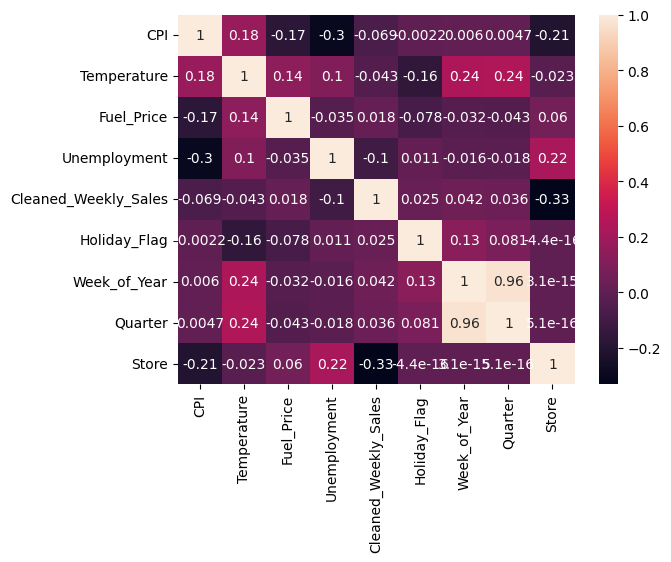

In [21]:
correlation  = df[['CPI','Temperature','Fuel_Price','Unemployment','Cleaned_Weekly_Sales','Holiday_Flag','Week_of_Year','Quarter','Store']].corr()
sns.heatmap(correlation,annot=True)

In [22]:
df.to_csv('Walmart_Cleaned_Data.csv', index=False)

### Train Model for Prediction

In [23]:
df.columns

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month_Name',
       'Week_of_Year', 'Quarter', 'christmas_week', 'is_christmas_week',
       'Cleaned_Weekly_Sales'],
      dtype='object')

In [24]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score
import numpy as np
X = df[['Store','Temperature','CPI','Unemployment','Fuel_Price','Holiday_Flag','is_christmas_week','Week_of_Year','Quarter']]
Y = df['Cleaned_Weekly_Sales']
x_train,x_test,y_train,y_test = train_test_split(X,Y,random_state=42,test_size=0.2)
model = RandomForestRegressor(n_estimators=80,random_state=42)
model.fit(x_train,y_train)
predictions = model.predict(x_test)
MSE = mean_squared_error(y_test,predictions)
print(f"The MSE is {MSE}")
print(f"The RMSE is {np.sqrt(MSE)}")
print(f"The R2 Square is {r2_score(y_test,predictions)}")



The MSE is 13231836010.612415
The RMSE is 115029.71794546145
The R2 Square is 0.9567424676011439
